This notebook provides a computational framework for the initial quality assessment and visualisation of 3D electron density reconstructions, verifying the integrity of the density map before attempting to build an atomic model.This code implements a dual-stage diagnostic pipeline that transitions from real-space density to Fourier-space frequency analysis. 

The first component extracts a central slice of the 3D volume, where the grayscale intensity variations allow researchers to delineate the molecular boundary and internal architecture of the protein against the surrounding vitreous ice. 

The second component calculates the power spectrum using a Fast Fourier Transform (FFT).

This spectral map is a vital indicator of structural determination quality, as a sharp and symmetrical distribution confirms that the data is free from common artifacts like motion blur or optical astigmatism. By utiliсing this notebook, it can be effectively quantified the signal-to-noise ratio and confirm the structural orientation of the complex, ensuring the dataset is sufficient for identifying high-resolution features or conformational tightening.

In [3]:
# pip install mrcfile

In [4]:
import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

def analyze_cryoem_map(map_path):
    # 1. Load the MRC file (the standard format for Cryo-EM maps)
    with mrcfile.open(map_path, mode='r') as mrc:
        data = mrc.data
        voxel_size = mrc.voxel_size.x  # In Angstroms
        
    print(f"Map Dimensions: {data.shape}")
    print(f"Voxel Size: {voxel_size:.3f} Å")

    # 2. Calculate the Power Spectrum (Frequency Content)
    # This helps visualize the resolution and signal quality
    fft_data = np.abs(np.fft.fftn(data))
    fft_shifted = np.fft.fftshift(fft_data)
    psd = np.log10(fft_shifted**2)

    # 3. Generate a Central Slice Visualization
    # Viewing the middle of the protein density
    mid = data.shape[0] // 2
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(data[mid, :, :], cmap='gray')
    plt.title('Central Slice (Density Map)')
    plt.colorbar(label='Electron Density')

    plt.subplot(1, 2, 2)
    plt.imshow(psd[mid, :, :], cmap='magma')
    plt.title('Power Spectrum (Frequency)')
    plt.colorbar(label='Log Power')

    plt.tight_layout()
    plt.show()

In [5]:
import gzip
import shutil

# In https://www.emdataresource.org/, surch for EMD-4343 and dowload "Primary Map, emd_4343.map.gz"
# Unzip emd_4343.map.gz and get the .mrc file
input_file = 'emd_4343.map.gz'
output_file = 'emd_4343.mrc'

with gzip.open(input_file, 'rb') as f_in:
    with open(output_file, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print(f"Extracted {input_file} to {output_file}")

Extracted emd_4343.map.gz to emd_4343.mrc


Map Dimensions: (376, 376, 376)
Voxel Size: 1.058 Å


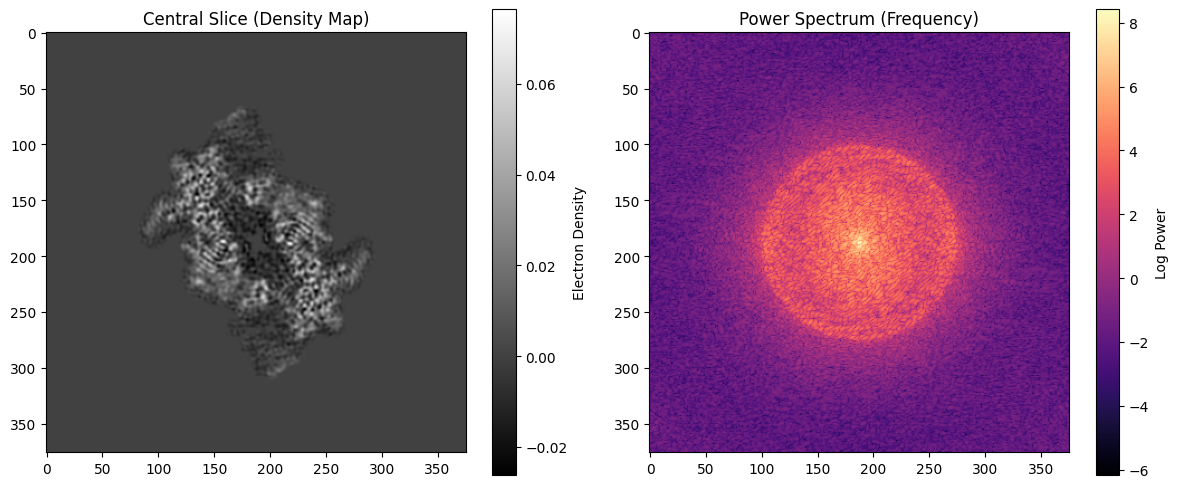

In [6]:
analyze_cryoem_map('emd_4343.mrc')

The visualisation illustrates a dual-stage diagnostic for Cryo-EM structural data, transitioning from real-space density to Fourier-space frequency analysis. The left panel shows a central slice of the 3D reconstruction, where the grayscale intensity represents the electron density of the protein complex; the distinct white and light-gray regions delineate the molecular boundary and internal architecture, while the dark areas represent the surrounding vitreous ice. Conversely, the right panel displays the power spectrum (the log-transformed magnitude of the Fourier Transform), which maps the signal distribution across various spatial frequencies. This spectral map is essential for structural determination, as a sharp, symmetrical distribution indicates a high-resolution reconstruction free from motion blur or optical astigmatism. By analysing these two outputs together, it can be confirmed the structural integrity of the E3 ligase complex, identifying conformational tightening or domain orientation, before proceeding to atomic model building and refinement.